# **Neural Network Basics with PyTorch**

## **1. Import Libraries**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets
from torchvision import transforms

from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

## **2. Device Configuration**

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


## **3. Data Transformation**

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor()
])

## **4. Download MNIST Dataset**

In [ ]:
train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

print(len(train_dataset))
print(len(test_dataset))

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 505kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.56MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.3MB/s]

60000
10000


## **5. Visualize Some Images**

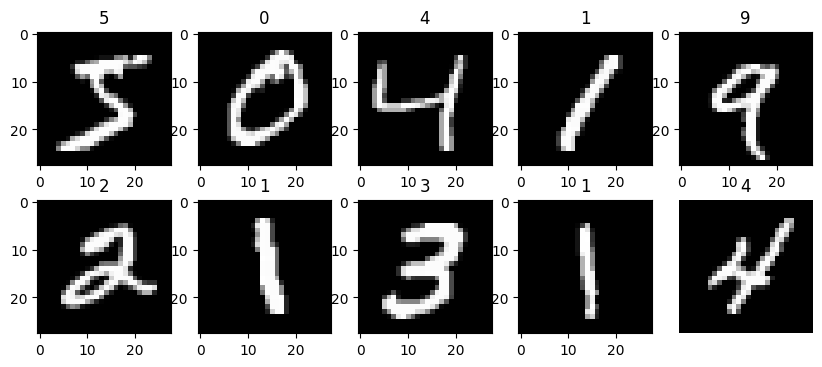

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i in range(10):
  image, label = train_dataset[i]
  ax = axes[i//5][i%5]
  ax.imshow(image.squeeze(), cmap='gray')
  ax.set_title(str(label))
ax.axis("off")
plt.show()

## **6. DataLoader**

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

## **7. Build Simple CNN**

In [ ]:
class SimpleCNN(nn.Module):
  def __init__(self):
    super().__init__()
    self.features = nn.Sequential(
        nn.Conv2d(
            in_channels=1,
            out_channels=32,
            kernel_size=3,
            padding=1
        ),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Conv2d(
            32,
            64,
            kernel_size=3,
            padding=1
        ),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(64 * 7 * 7, 128),
        nn.ReLU(),
        nn.Linear(128, 10)
    )

  def forward(self, x):
    x = self.features(x)
    x = self.classifier(x)
    return x

model = SimpleCNN().to(device)
print(model)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


## **8. Loss Function**

In [ ]:
criterion = nn.CrossEntropyLoss()

## **9. Optimizer**

In [ ]:
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

## **10. Training Function**

In [ ]:
def train_one_epoch():
  model.train()
  running_loss = 0
  correct = 0
  total = 0

  for images, labels in train_loader:
    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()
    outputs = model(images)

    loss = criterion(outputs, labels)
    loss.backward()

    optimizer.step()

    running_loss += loss.item()
    _, predicted = outputs.max(1)

    total += labels.size(0)
    correct += predicted.eq(labels).sum().item()

  accuracy = 100 * correct/total
  avg_loss = running_loss / len(train_loader)

  return avg_loss, accuracy

## **11. Evaluation Function**

In [ ]:
def evaluate():
  model.eval()
  correct = 0
  total = 0
  with torch.no_grad():
    for images, labels in test_loader:
      images = images.to(device)
      labels = labels.to(device)

      outputs = model(images)
      _, predicted = outputs.max(1)

      total += labels.size(0)
      correct += predicted.eq(labels).sum().item()

  return 100 * correct/total

### **12. Main Training Loop**

In [ ]:
epochs = 5
for epoch in range(epochs):
  train_loss, train_acc = train_one_epoch()
  test_acc = evaluate()

  print(
    f"Epoch {epoch+1} | "
    f"Loss: {train_loss:.4f} | "
    f"Train Acc: {train_acc:.2f}% | "
    f"Test Acc: {test_acc:.2f}%"
  )

Epoch 1 | Loss: 0.1892 | Train Acc: 94.23% | Test Acc: 98.09%
Epoch 2 | Loss: 0.0519 | Train Acc: 98.39% | Test Acc: 98.63%
Epoch 3 | Loss: 0.0362 | Train Acc: 98.87% | Test Acc: 98.77%
Epoch 4 | Loss: 0.0273 | Train Acc: 99.11% | Test Acc: 98.77%
Epoch 5 | Loss: 0.0212 | Train Acc: 99.34% | Test Acc: 98.86%


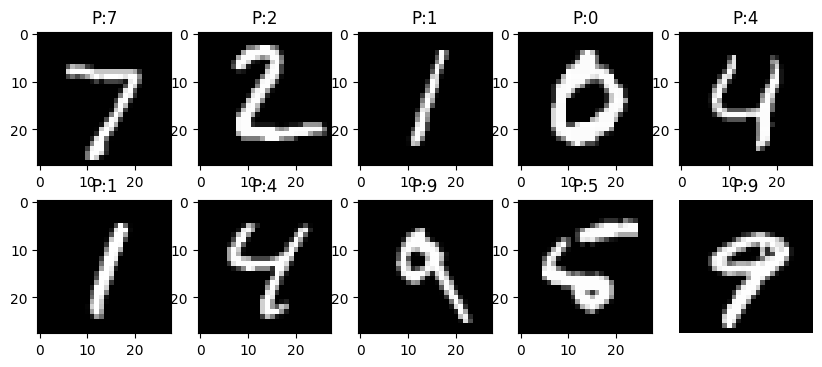

In [ ]:
images, labels = next(iter(test_loader))
images = images.to(device)
outputs = model(images)
_, preds = outputs.max(1)
images = images.cpu()
preds = preds.cpu()
fig, axes = plt.subplots(2,5, figsize=(10,4))

for i in range(10):
  ax = axes[i//5][i%5]
  ax.imshow(images[i].squeeze(), cmap="gray")
  ax.set_title(f"P:{preds[i].item()}")

ax.axis("off")

plt.show()